# Phần Duy: hiểu dữ liệu và mô hình

Notebook học từng bước, đọc kết quả v2 đã chạy. Không chấm test hoặc huấn luyện lại. Đọc hướng dẫn `docs/team/duy_implementation_and_learning.md` để biết toàn bộ lý do và nguồn.

In [1]:
from pathlib import Path
import sys
import json
import platform

ROOT = Path.cwd()
if not (ROOT / "src/steel").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src/steel").is_dir():
    raise FileNotFoundError("Mở notebook từ repo hoặc thư mục notebooks")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display, Image
from src.steel.preprocessing import load_official_raw, BASE_FEATURES, TARGET, build_supervised_rows, split_supervised_rows
from src.steel.duy_forecasting import forecast_features
from src.steel.duy_inference import DuyForecaster
RUN = ROOT / "reports/steel/duy_2026-10-02"
print("Python:", platform.python_version())
print("Run:", RUN.name)


Python: 3.14.3
Run: duy_2026-10-02


## 1. Kiểm dữ liệu gốc

35040 hàng không đồng nghĩa đã sẵn sàng học. Kiểm hash, timestamp, missing, trùng và phạm vi; giữ raw nguyên trạng.

In [2]:
raw, audit = load_official_raw(ROOT / "data/steel/raw/Steel_industry_data.csv")
display(pd.Series(audit)[["raw_rows", "raw_columns", "missing_cells", "duplicate_timestamps", "raw_order_backward_jumps", "zero_usage_rows"]])

raw_rows                    35040
raw_columns                    11
missing_cells                   0
duplicate_timestamps            0
raw_order_backward_jumps      365
zero_usage_rows                 1
dtype: object

## 2. EDA chỉ dùng train

Hình giờ–thứ mô tả chu kỳ, không chứng minh nguyên nhân sản xuất. Histogram cho thấy mức tải thấp/cao khác nhau.

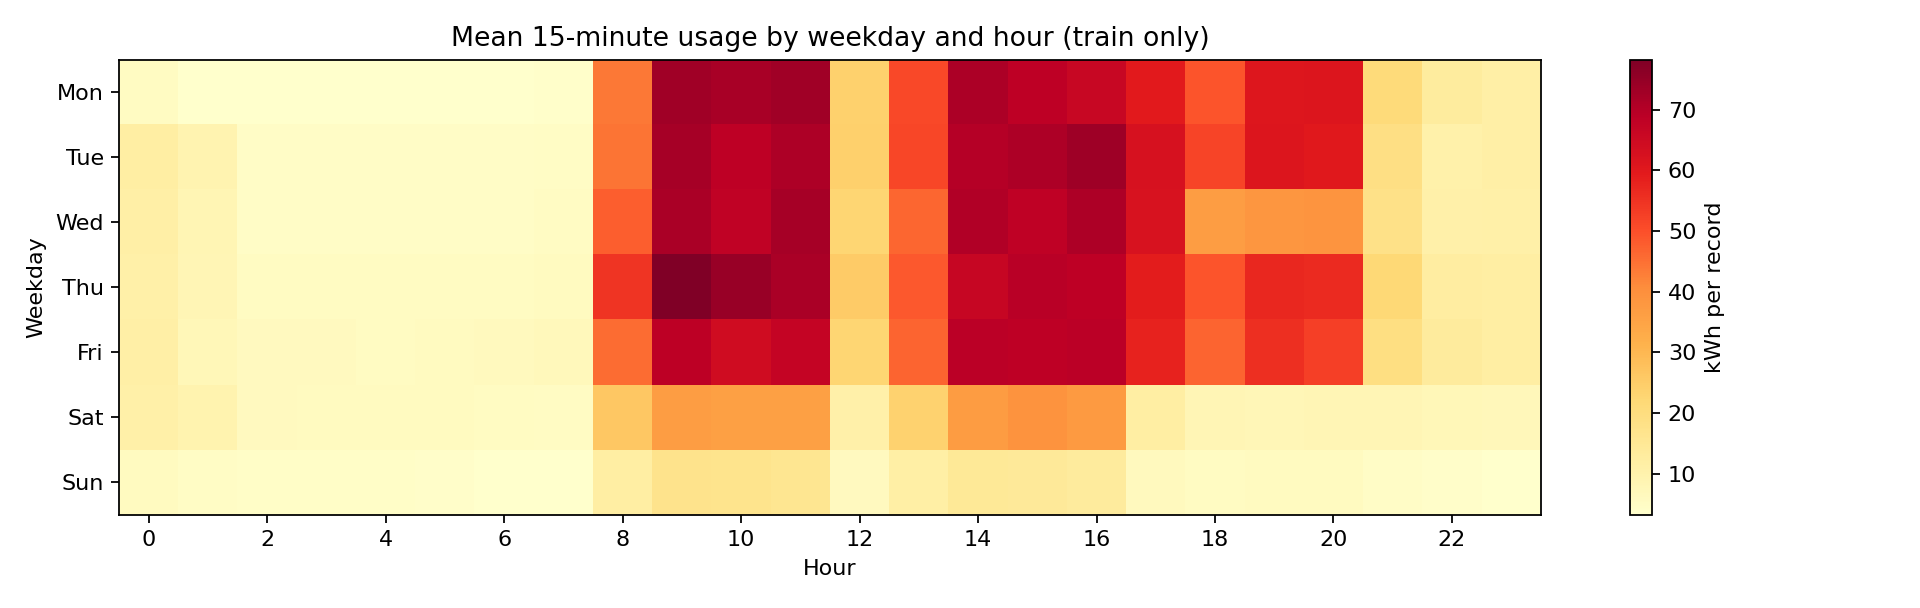

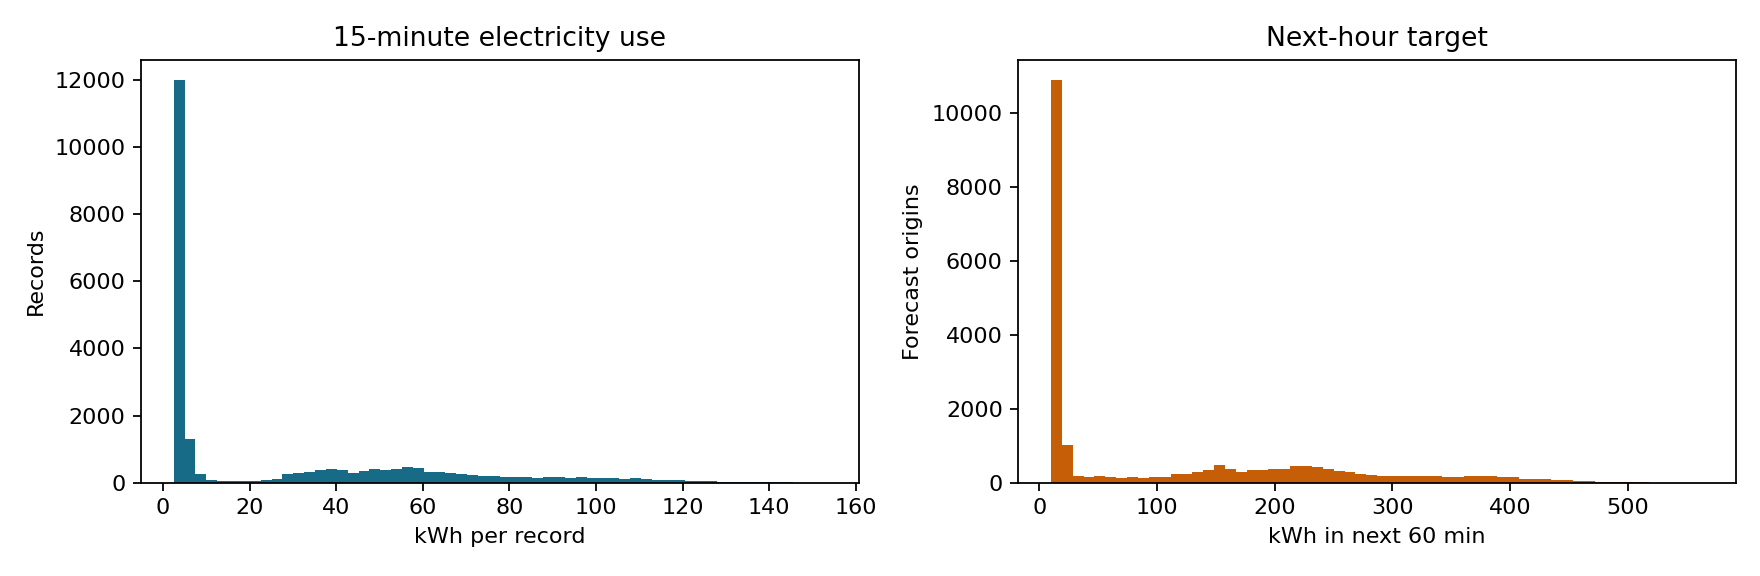

In [3]:
display(Image(filename=str(RUN / "figures/steel_train_hour_weekday.png")))
display(Image(filename=str(RUN / "figures/steel_train_distributions.png")))

## 3. Target và feature

Target là tổng Usage(t+1..t+4). Feature chỉ lấy dữ liệu <=t. Thay future để kiểm leakage phải làm trên bản copy, không sửa CSV gốc.

In [4]:
rows = build_supervised_rows(raw)
rows.loc[:, list(BASE_FEATURES)] = forecast_features(raw).to_numpy()
splits, split_audit = split_supervised_rows(rows)
display(splits["train"].loc[:2, ["observation_time", TARGET, "usage_lag_0", "usage_sum_last_1h"]])
display(json.loads((RUN / "target_examples.json").read_text(encoding="utf-8")))

,observation_time,target_next_60m_kWh,usage_lag_0,usage_sum_last_1h
0,2018-01-08 00:00:00,14.36,4.68,14.98
1,2018-01-08 00:15:00,13.93,3.78,15.52
2,2018-01-08 00:30:00,13.86,3.38,15.26


{'examples': [{'observation_time': '2018-01-08 00:00:00',
   'next_four_kWh': [3.78, 3.38, 3.31, 3.89],
   'hand_sum_kWh': 14.36},
  {'observation_time': '2018-02-22 02:00:00',
   'next_four_kWh': [6.08, 6.05, 5.98, 5.9],
   'hand_sum_kWh': 24.01},
  {'observation_time': '2018-07-28 08:00:00',
   'next_four_kWh': [18.72, 42.44, 51.19, 35.75],
   'hand_sum_kWh': 148.1}]}

## 4. Split theo thời gian

672 hàng thiếu lag tuần; 12 nhãn qua ba ranh giới; 4 hàng cuối thiếu nhãn. Không shuffle. Oct/Nov-Dec chỉ bàn giao, chưa chấm trong phần Duy.

In [5]:
display(pd.Series(split_audit["split_rows"], name="rows"))
display(pd.Series(split_audit["row_disposition_counts"], name="rows"))

train          22652
validation      2876
calibration     2972
test            5852
Name: rows, dtype: int64

future_label_unavailable            4
included                        34352
insufficient_history              672
label_crosses_split_boundary       12
Name: rows, dtype: int64

## 5. Baseline và hai phương pháp ML

Baseline đo lợi ích của AI. Ridge dùng StandardScaler fit train; HGB không cần scaling. Chọn trên validation, không lấy model thắng test để chọn.

,model,train_mae_kWh,mae_kWh,rmse_kWh,peak_mae_kWh
0,hgb_31_leaves,14.424265,15.882850,32.047494,68.696315
1,hgb_15_leaves,17.313016,16.317688,32.593441,68.277323
2,last_hour,43.476101,32.323773,69.115457,106.541075
3,ridge_alpha_1,41.388573,33.016808,50.966902,84.395274
4,ridge_alpha_100,41.426510,33.030682,51.011484,85.535666
5,previous_week,58.049827,43.454343,81.904596,128.845161
6,previous_day,63.437929,47.231881,91.001553,229.308387
7,diurnal_train_mean,50.631155,49.971931,78.689422,141.832740


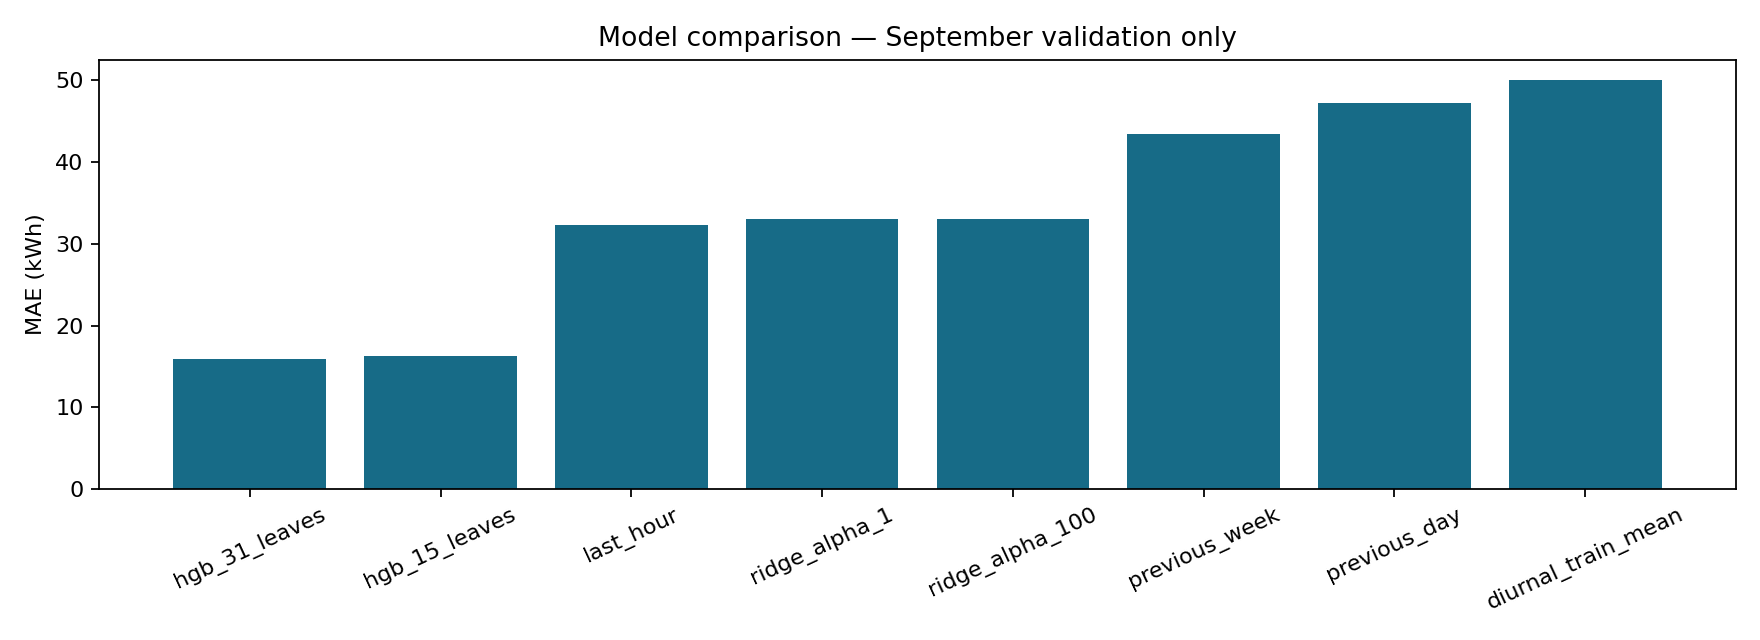

In [6]:
leaderboard = pd.read_csv(RUN / "validation_leaderboard.csv")
display(leaderboard[["model", "train_mae_kWh", "mae_kWh", "rmse_kWh", "peak_mae_kWh"]])
display(Image(filename=str(RUN / "figures/validation_model_comparison.png")))

## 6. Hiểu ca sai

MAE tổng tốt vẫn có thể sai lớn ở vùng cao. File ca sai là dữ liệu validation phục vụ học/kiểm, không đưa actual tương lai vào giao diện replay.

,observation_time,target_next_60m_kWh,prediction_kWh,error_kWh,absolute_error_kWh
0,2018-09-10 18:00:00,26.04,298.862924,272.822924,272.822924
1,2018-09-05 08:00:00,345.70,111.824441,-233.875559,233.875559
2,2018-09-07 08:00:00,310.42,94.018927,-216.401073,216.401073
3,2018-09-10 17:45:00,70.03,267.783288,197.753288,197.753288
4,2018-09-11 08:00:00,355.28,158.054087,-197.225913,197.225913


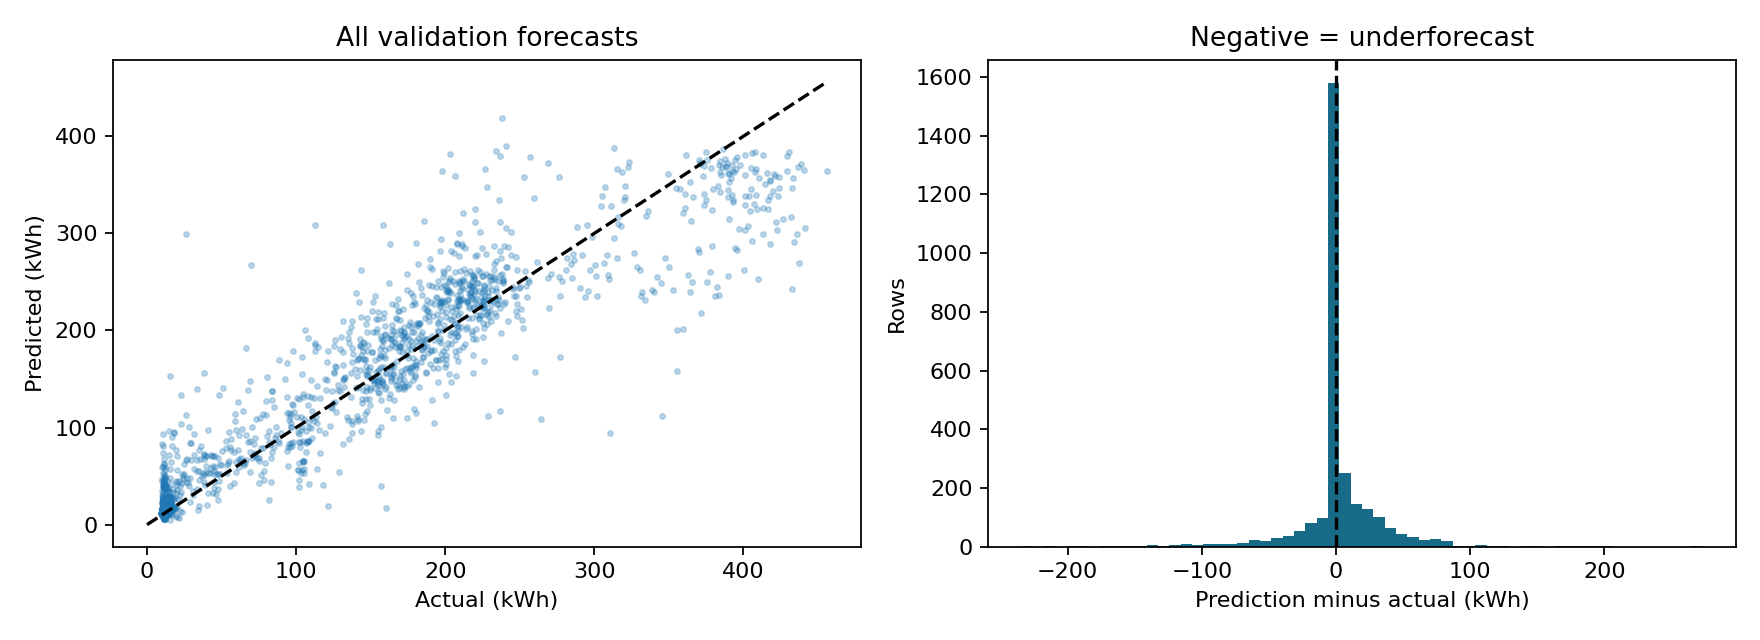

In [7]:
display(pd.read_csv(RUN / "largest_validation_errors.csv").head(5))
display(Image(filename=str(RUN / "figures/validation_errors.png")))

## 7. Một dự báo bằng lịch sử tới t

Không có actual tương lai trong output. Chưa có policy nên trạng thái là forecast-only, không phải an toàn hoặc cảnh báo.

In [8]:
issue = pd.Timestamp("2018-09-01 08:00:00")
history = raw.loc[raw.observation_time <= issue, ["observation_time", "Usage_kWh"]].tail(673)
forecaster = DuyForecaster(RUN)
display(forecaster.predict(history, issue))

{'issue_time': '2018-09-01 08:00:00',
 'forecast_start': '2018-09-01 08:15:00',
 'forecast_end': '2018-09-01 09:00:00',
 'predicted_next_60m_kWh': 150.0854901192002,
 'model_name': 'hgb_31_leaves',
 'model_sha256': '3de06129bd2a04a940516d6e08816df0687dfe4e56ca80eb7600fbf2c812f66e',
 'feature_implementation': 'duy_numpy_windows_v1',
 'status': 'forecast_only_no_alert_policy'}

## 8. Bạn tự luyện

- Tính tay target ở ba mốc trong file ví dụ.
- Giải thích vì sao lag0 hợp lệ và rolling centered không hợp lệ.
- Đọc tests/test_duy_forecasting.py: future perturbation, scaler train-only, batch/replay.
- Giải thích Ridge có RMSE thấp hơn baseline nhưng MAE cao hơn.
- Đọc ghi chú Khánh/Huy, bàn giao đúng model/schema rồi mới calibration/demo.

Nguồn: [UCI Steel](https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption), [scikit-learn leakage](https://scikit-learn.org/1.8/common_pitfalls.html), [time-series lag features](https://scikit-learn.org/1.8/auto_examples/applications/plot_time_series_lagged_features.html), [Jay Lee 2020](https://doi.org/10.1007/978-981-15-2144-7).